In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # needed for 3D plotting
import numpy as np
from scipy.interpolate import griddata

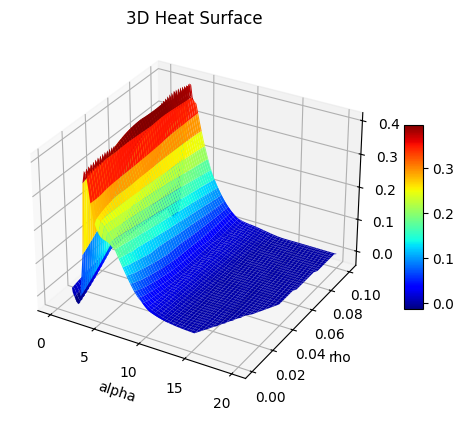

In [2]:
# Load CSV file
file_path = r".\results\bayes_results_f1_rho_alpha.csv"  # replace with your file path
df = pd.read_csv(file_path)

# Choose columns for plotting
x_col = "alpha"   # replace with your column name
y_col = "rho"   # replace with your column name
z_col = "F1 Score"   # replace with your column name

y = df[y_col].values
z = df[z_col].values

# Create grid
x = df[x_col].values
xi = np.linspace(min(x), max(x), 100)
yi = np.linspace(min(y), max(y), 100)
X_grid, Y_grid = np.meshgrid(xi, yi)

# Interpolate
Z_grid = griddata((x, y), z, (X_grid, Y_grid), method='cubic')

# Plot
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(
    X_grid,
    Y_grid,
    Z_grid,
    cmap='jet',        # heat colormap
    edgecolor='none'   # smooth surface
)

# Add color bar
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10)

ax.set_xlabel(x_col)
ax.set_ylabel(y_col)
ax.set_zlabel(z_col)

plt.title("3D Heat Surface")
plt.show()

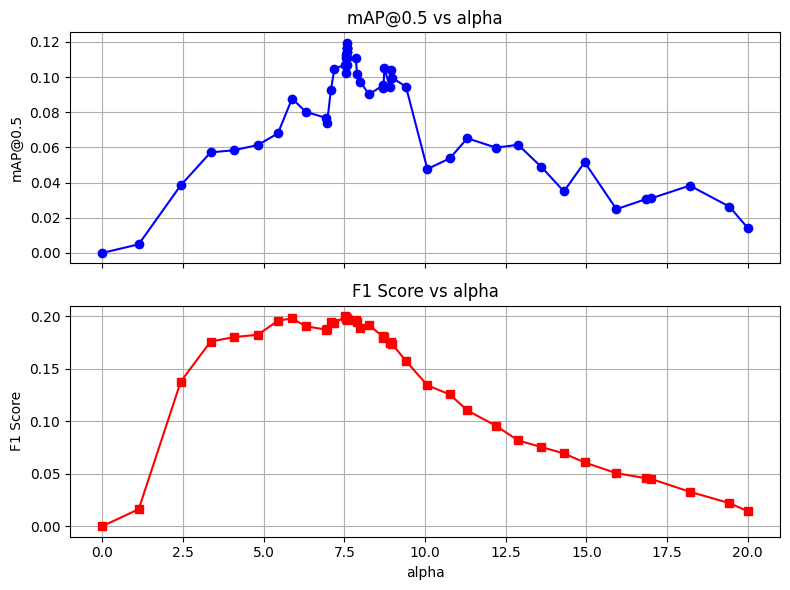

In [3]:
# Load CSV file
file_path = r".\results\bayes_results_MAP_alpha.csv"  # replace with your file path
df = pd.read_csv(file_path)

# Choose columns
x_col = "alpha"   # replace with your column name
y1_col = "mAP@0.5"   # replace with your column name
y2_col = "F1 Score"     # second line

# Sort by X
df_sorted = df.sort_values(by=x_col)

# Create subplots
fig, axs = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

# First subplot
axs[0].plot(df_sorted[x_col], df_sorted[y1_col], marker='o', color='blue')
axs[0].set_ylabel(y1_col)
axs[0].set_title(f"{y1_col} vs {x_col}")
axs[0].grid(True)

# Second subplot
axs[1].plot(df_sorted[x_col], df_sorted[y2_col], marker='s', color='red')
axs[1].set_xlabel(x_col)
axs[1].set_ylabel(y2_col)
axs[1].set_title(f"{y2_col} vs {x_col}")
axs[1].grid(True)

plt.tight_layout()
plt.show()